
# Spotify Music Recommendation System

**Objective:**
Build a content-based recommendation system that suggests
similar songs based on Spotify audio features.

> Workflow:

1. Load Dataset
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Feature Scaling
6. KMeans Clustering
7. Cosine Similarity
8. Recommendation Function
9. Save Model
    

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA

import joblib


In [2]:
df = pd.read_csv("/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv")

print("Shape :", df.shape)

df.head()

Shape : (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


# Data Cleaning

In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

print(df.shape)

(114000, 20)


In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

artists       1
album_name    1
track_name    1
dtype: int64

In [7]:
df.dropna(inplace=True)

print(df.shape)

(113999, 20)


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 450


In [9]:
df.drop_duplicates(subset="track_id", inplace=True)

print(df.shape)

(89740, 20)


In [10]:
df.isnull().sum().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

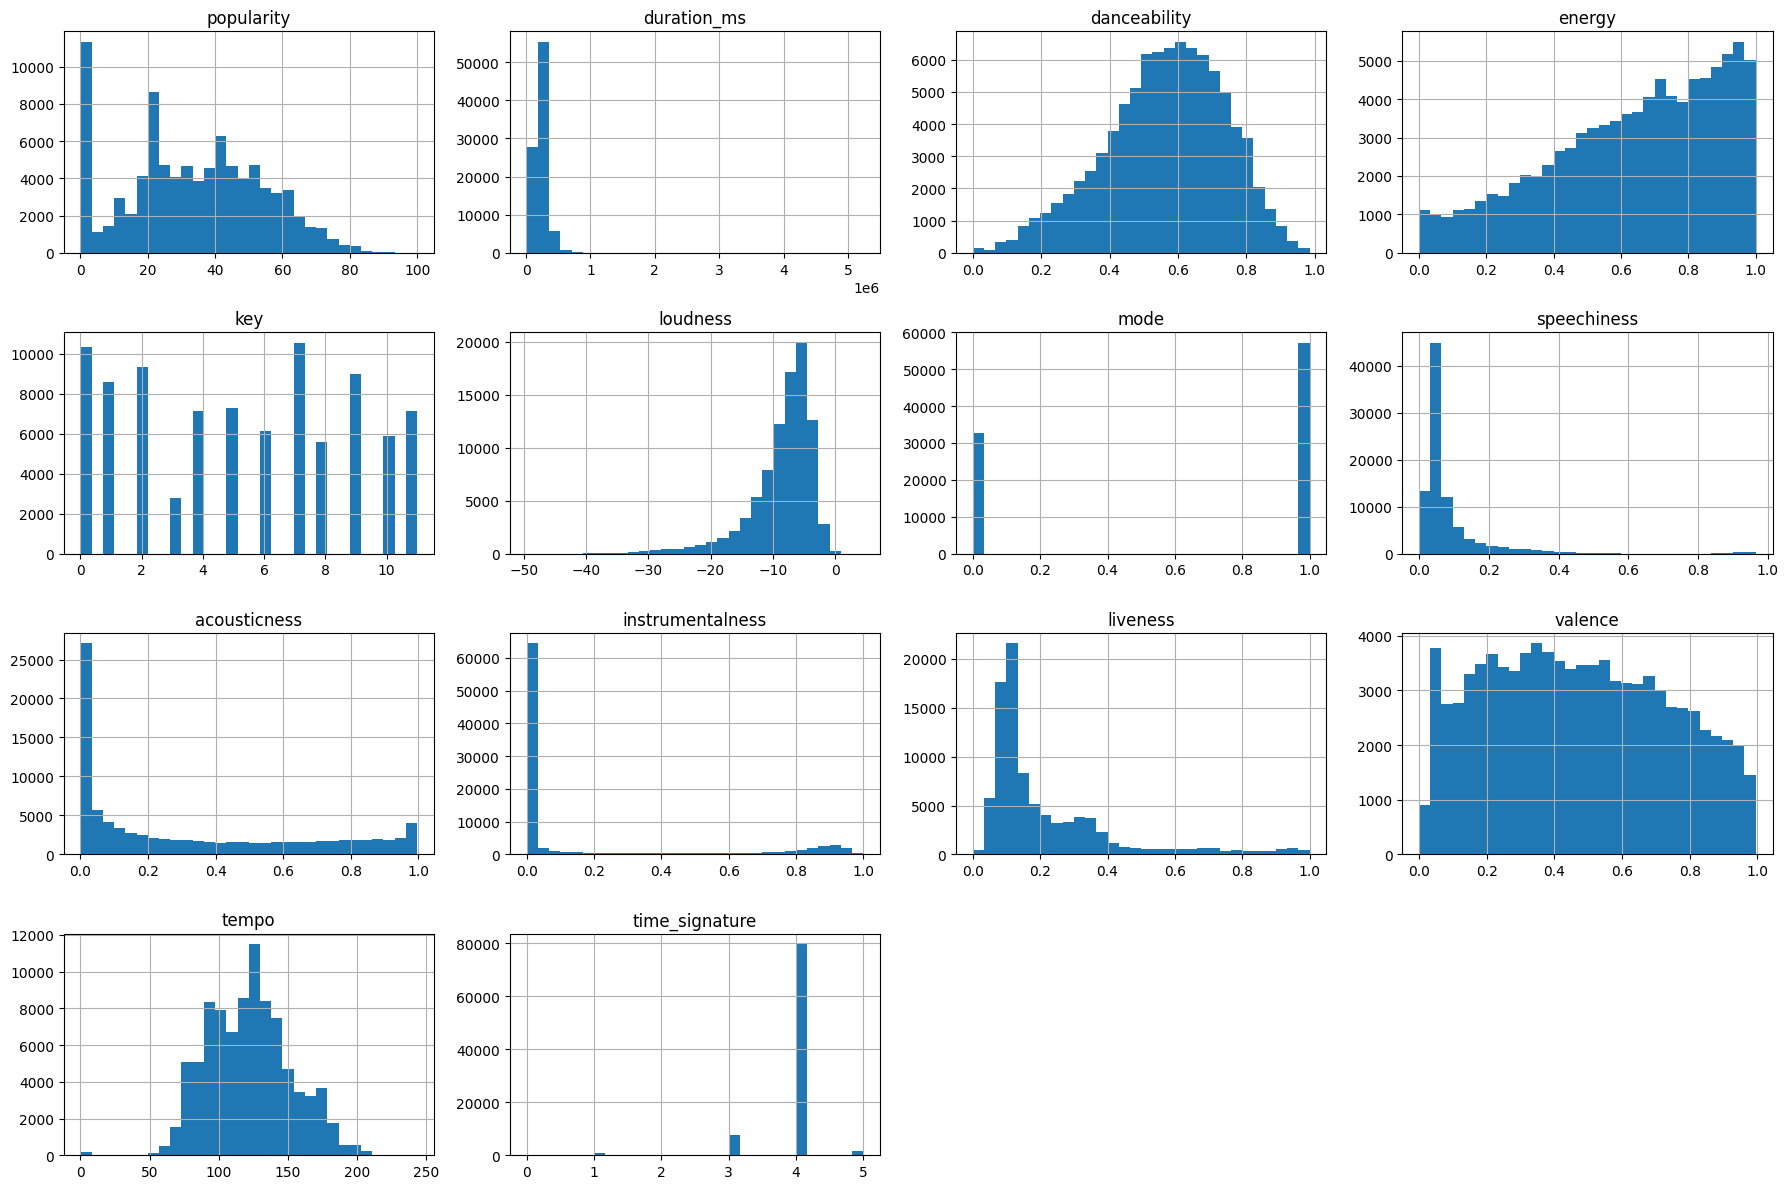

In [12]:
df[numerical_columns].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()

plt.show()

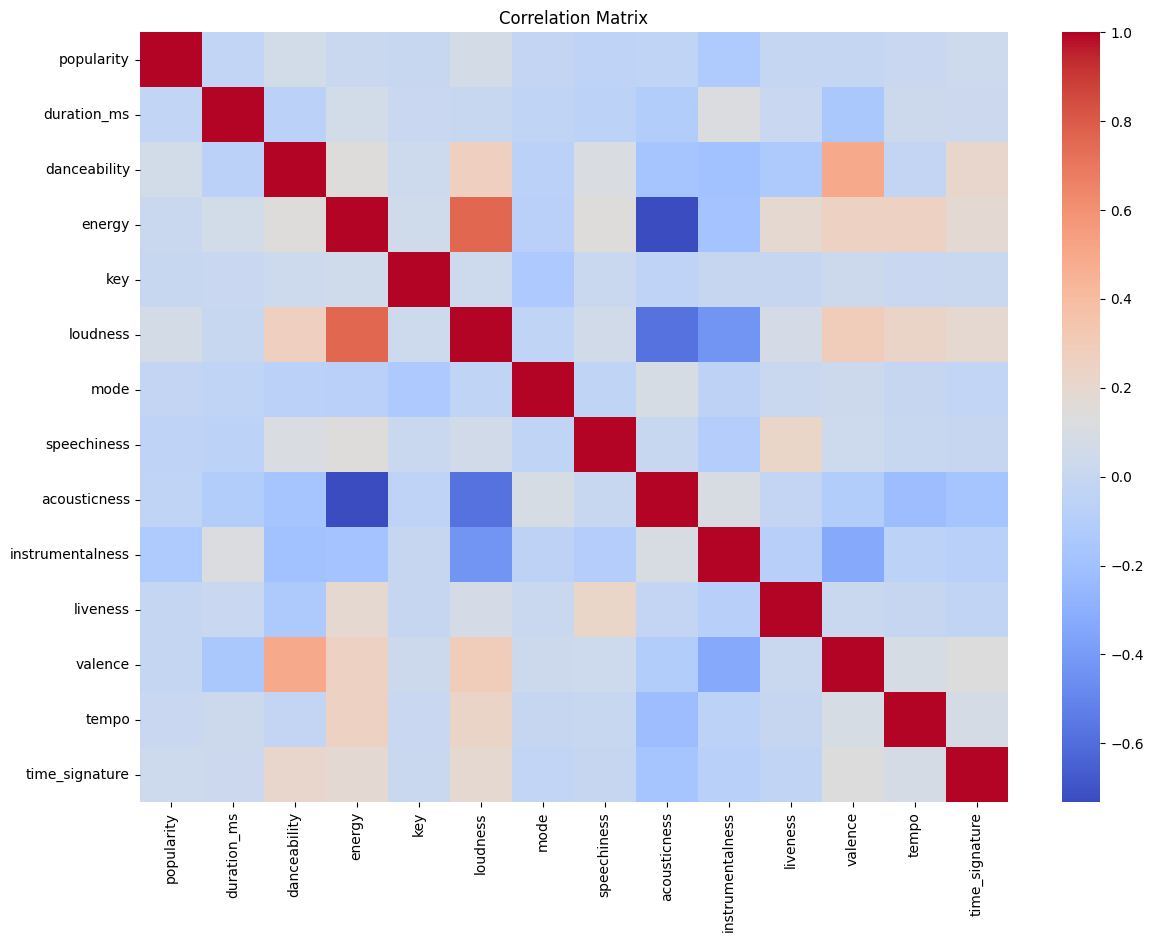

In [13]:
plt.figure(figsize=(14,10))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

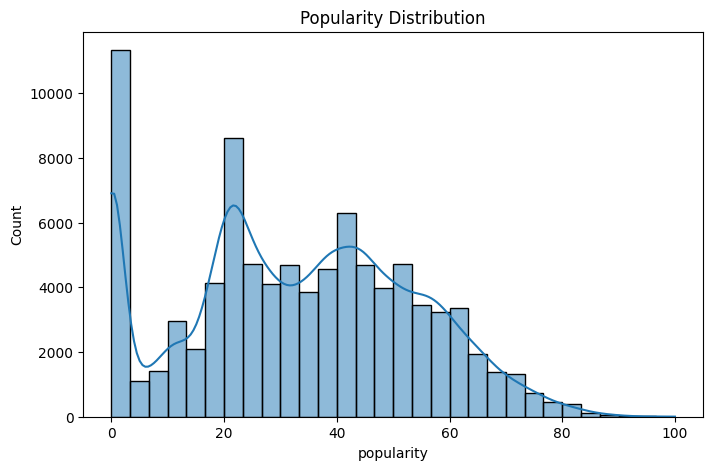

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True
)

plt.title("Popularity Distribution")

plt.show()

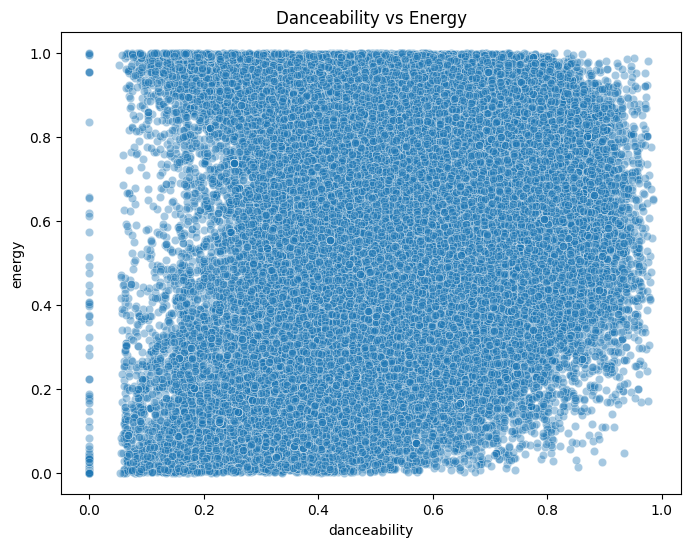

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="energy",
    alpha=0.4
)

plt.title("Danceability vs Energy")

plt.show()

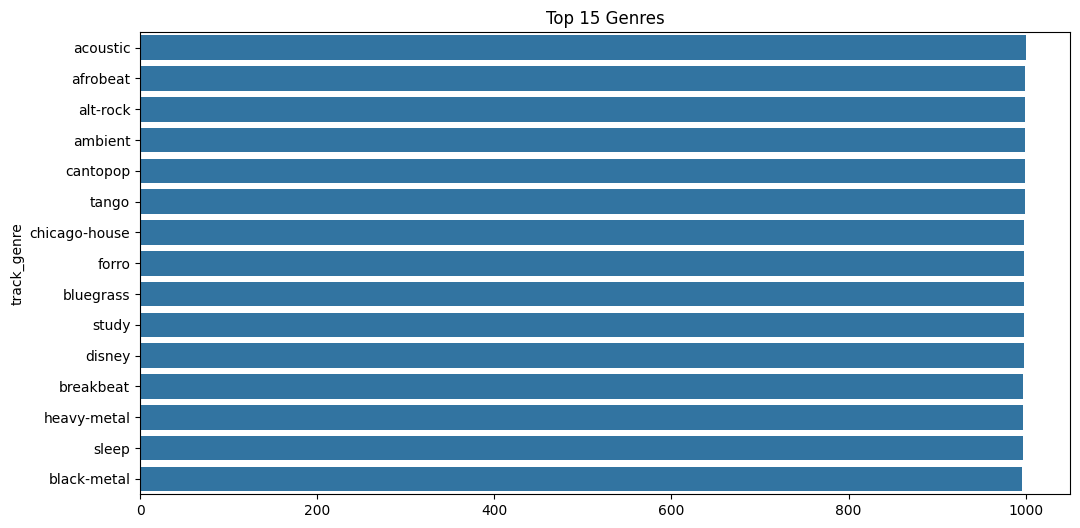

In [16]:
top_genres = (
    df["track_genre"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Genres")

plt.show()

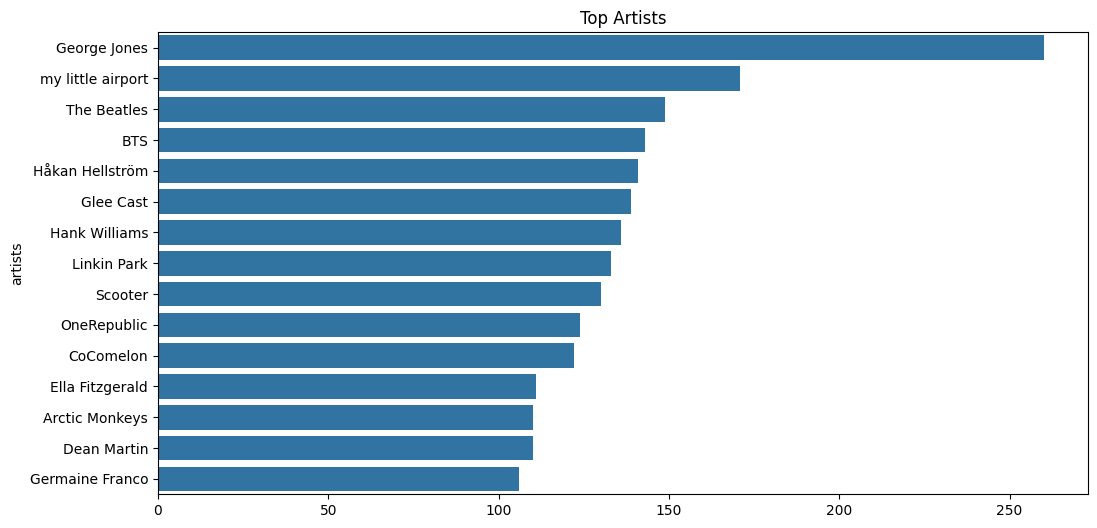

In [17]:
top_artists = (
    df["artists"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top Artists")

plt.show()

# Feature Selection
> Instead of using text columns like:
* track_name
* album_name
* artists
* genre
  
The recommendations will be based on Spotify's audio features.

In [18]:
features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "time_signature"
]

In [19]:
X = df[features]
X.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666,4
1,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610,4
2,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826,4
3,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933,3
4,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853,4


In [20]:
print(X.shape)

(89740, 13)


# Feature Scaling

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Shape :", X_scaled.shape)


Scaled Shape : (89740, 13)


In [22]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

scaled_df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.644253,-0.675975,-1.203275,0.335727,-1.324621,0.490458,-0.875166,-0.535482,0.723656,0.934047,-1.133599,0.013472,0.226216
1,-0.804604,-1.825602,-1.203275,-1.673087,0.754933,-0.098364,1.760810,-0.535468,-0.595078,-0.770269,-1.479843,-0.704186,0.226216
2,-0.702731,-1.073473,-1.484183,-0.236524,0.754933,-0.280219,-0.349626,-0.535485,-0.512978,-1.329497,-1.518259,-0.162188,0.226216
3,-1.676182,-2.240247,-1.484183,-1.918228,0.754933,-0.451480,1.704650,-0.535266,-0.436009,-1.241999,1.981635,-0.240925,-1.979174
4,0.315996,-0.746122,-0.922368,-0.226373,0.754933,-0.307585,0.415925,-0.535485,-0.687954,-1.150696,-0.070030,-0.268195,0.226216


# Finding the Optimal Number of Clusters (Elbow Method)

In [23]:
inertia = []

cluster_range = range(2,21)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

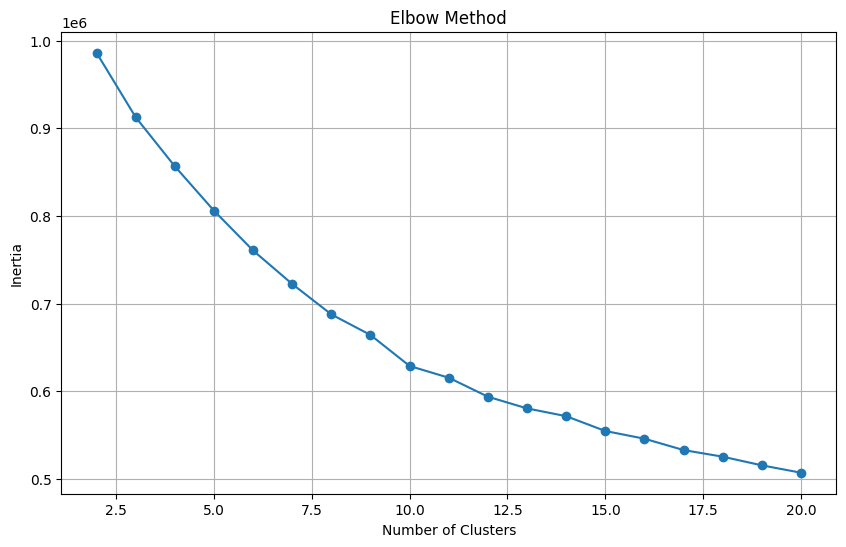

In [24]:
plt.figure(figsize=(10,6))

plt.plot(
    cluster_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

# Silhouette Score

In [25]:
scores = []

cluster_range = range(2, 11)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,  
        random_state=42
    )

    scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.2155
k=3, silhouette=0.1105
k=4, silhouette=0.1136
k=5, silhouette=0.1138
k=6, silhouette=0.1152
k=7, silhouette=0.1186
k=8, silhouette=0.1236
k=9, silhouette=0.1160
k=10, silhouette=0.1307


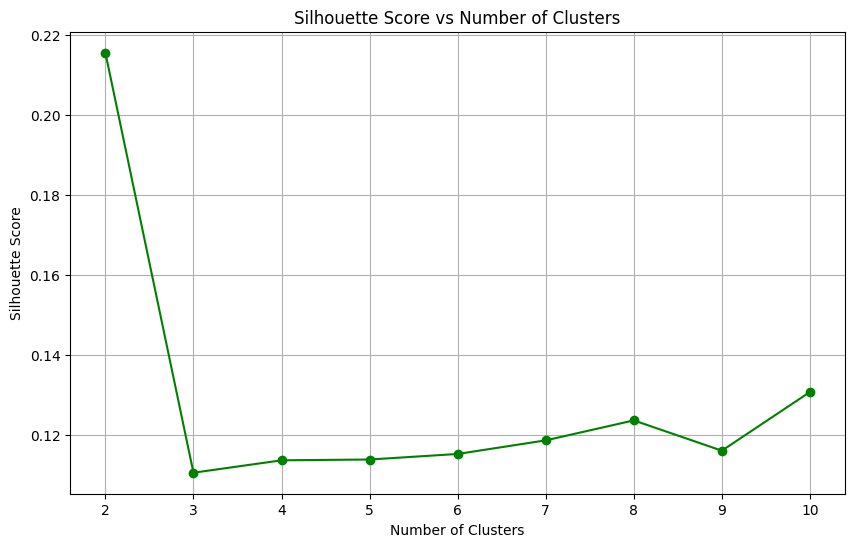

In [26]:
plt.figure(figsize=(10,6))

plt.plot(
    cluster_range,
    scores,
    marker="o",
    color="green"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Number of Clusters")

plt.grid(True)

plt.show()

# Train the K-Means Model

In [27]:
kmeans = KMeans(
    n_clusters= 10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("Model Trained Successfully!")

Model Trained Successfully!


In [28]:
df["cluster"] = clusters

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,3
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3


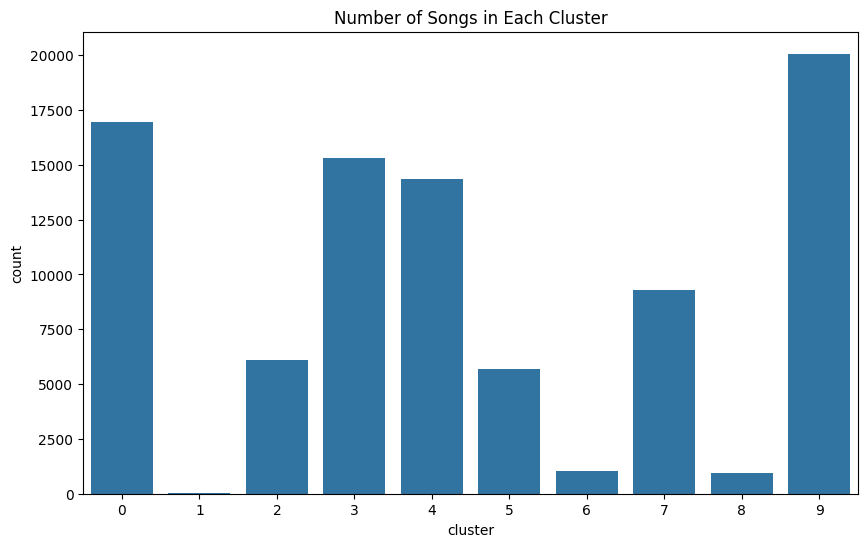

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="cluster"
)

plt.title("Number of Songs in Each Cluster")

plt.show()

In [30]:
df["cluster"].value_counts().sort_index()

cluster
0    16956
1       40
2     6078
3    15292
4    14361
5     5704
6     1024
7     9275
8      949
9    20061
Name: count, dtype: int64

# Visualizing Clusters using PCA

In [31]:
pca = PCA(n_components=2)

reduced_features = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    reduced_features,
    columns=["PC1","PC2"]
)

pca_df["cluster"] = clusters

pca_df.head()

,PC1,PC2,cluster
0,0.730748,0.862893,0
1,-3.167249,1.485370,3
2,-1.352967,0.015881,3
3,-3.635836,-0.144571,3
4,-0.894508,0.469319,3


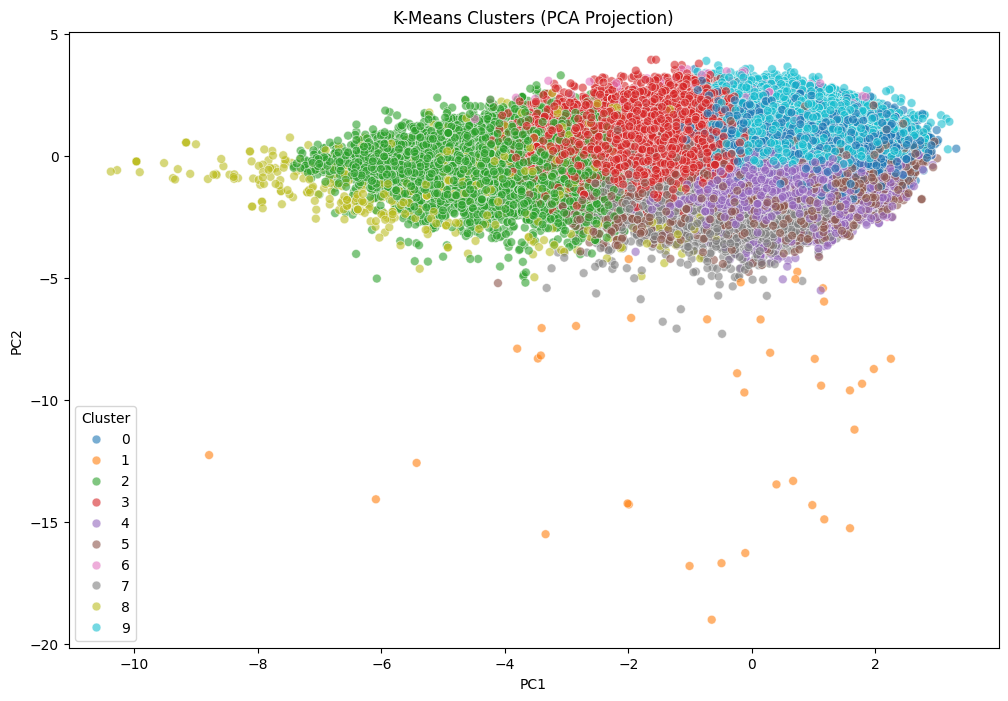

In [32]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=40
)

plt.title("K-Means Clusters (PCA Projection)")

plt.legend(title="Cluster")

plt.show()

In [33]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")

print(np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.22935269 0.11795028]

Total Explained Variance:
0.347302965632891


In [34]:
joblib.dump(scaler, "scaler.joblib")
joblib.dump(kmeans, "kmeans.joblib")

print("Models Saved Successfully!")

Models Saved Successfully!


# Cosine Similarity

In [35]:
feature_columns = features

scaled_clusters = {}

for cluster_id in sorted(df["cluster"].unique()):

    cluster_df = df[df["cluster"] == cluster_id]

    scaled_clusters[cluster_id] = scaler.transform(
        cluster_df[feature_columns]
    )

# Recommendation Function

In [36]:
def recommend(song_name, artist_name=None, n=10, restrict_genre=None):

    matches = df[df["track_name"].str.lower() == song_name.lower()]

    if artist_name is not None:
        matches = matches[matches["artists"] == artist_name]

    if matches.empty:
        print("Song not found!")
        return []

    idx = matches.index[0]

    cluster = df.loc[idx, "cluster"]

    cluster_df = df[df["cluster"] == cluster].copy()

    cluster_scaled = scaled_clusters[cluster]

    local_idx = cluster_df.index.get_loc(idx)

    similarity = cosine_similarity(
        cluster_scaled[local_idx].reshape(1, -1),
        cluster_scaled
    ).flatten()

    scores = list(enumerate(similarity))

    if restrict_genre:
        allowed_positions = set(
            cluster_df.index.get_loc(i)
            for i in cluster_df[cluster_df.track_genre == restrict_genre].index
        )
        scores = [(i, s) for i, s in scores if i in allowed_positions]

    recommendations = []
    seen = set()

    for i, score in scores:

        song = cluster_df.iloc[i]

        key = (song.track_name, song.artists)

        if key in seen:
            continue

        seen.add(key)

        if song.track_name.lower() == song_name.lower():
            continue

        recommendations.append((song, score))

        if len(recommendations) == n:
            break

    return recommendations
    

# Test the Recommendation System

In [37]:
for song, score in recommend("Believer", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.3543  All I Want For Christmas Is A Real Good Tan — Chord Overstreet  [acoustic]
0.4176  The Haves — Eddie Vedder  [acoustic]
0.2908  Speak Your Mind (From the Netflix Series "We The People") — Brandi Carlile  [acoustic]
0.2969  The Enemy — Andrew Belle  [acoustic]
0.9748  Sky's Still Blue — Andrew Belle  [acoustic]
0.2096  A Drop In the Ocean — Ron Pope  [acoustic]
0.5190  Light Me Up — Ingrid Michaelson  [acoustic]
-0.0254  Fairytale Of New York — KT Tunstall  [acoustic]
0.2921  Boston — Augustana  [acoustic]
0.9341  Living in the Shadows — Matthew Perryman Jones  [acoustic]


In [38]:
for song, score in recommend("Shape Of You", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.7580  And I Love Her — Kurt Cobain  [acoustic]
0.5782  death bed (coffee for your head) — Andrew Foy;Renee Foy  [acoustic]
0.8583  Chi Mai — Joseph Sullinger  [acoustic]
0.8244  Mujer con Abanico — Agustín Amigó;Nylonwings  [acoustic]
0.4891  La La La (Something In the Rain, Pt. 2) [Music from the Original TV Series] — Rachael Yamagata  [acoustic]
0.6547  Love Nwantiti — Andrew Foy  [acoustic]
0.5546  Asleep Among Endives — Ichiko Aoba  [acoustic]
0.6372  River Flows In You — Sungha Jung  [acoustic]
0.5633  Guaranteed - Humming Version — Eddie Vedder  [acoustic]
0.3924  bouquet — Ichiko Aoba  [acoustic]


In [39]:
for song, score in recommend("Aaftaab", artist_name="The Local Train", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.7888  Ghost - Acoustic — Ben Woodward  [acoustic]
0.4667  To Begin Again — Ingrid Michaelson;ZAYN  [acoustic]
0.4898  Can't Help Falling In Love — Kina Grannis  [acoustic]
0.5668  Hold On — Chord Overstreet  [acoustic]
0.5910  Say Something — A Great Big World;Christina Aguilera  [acoustic]
0.5073  Hunger — Ross Copperman  [acoustic]
0.6082  Give Me Your Forever — Zack Tabudlo  [acoustic]
0.5510  I Won't Give Up — Jason Mraz  [acoustic]
0.5147  Solo — Dan Berk  [acoustic]
0.7280  Bad Liar — Anna Hamilton  [acoustic]


In [42]:
# Same search, but staying within the source genre
for song, score in recommend("Aaftaab", artist_name="The Local Train", n=10, restrict_genre="indian"):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.9068  Gul — Anuv Jain  [indian]
0.5312  Kesariya (From "Brahmastra") — Pritam;Arijit Singh;Amitabh Bhattacharya  [indian]
0.6387  Rasiya Reprise (From "Brahmastra") — Pritam;Arijit Singh;Amitabh Bhattacharya  [indian]
0.4596  Deva Deva (From "Brahmastra") — Pritam;Arijit Singh;Amitabh Bhattacharya;Jonita Gandhi  [indian]
0.6443  Kalank (Title Track) — Pritam;Arijit Singh  [indian]
0.4647  Phir Na Aisi Raat Aayegi (From "Laal Singh Chaddha") — Pritam;Arijit Singh;Amitabh Bhattacharya  [indian]
0.5218  Kabira — Pritam;Tochi Raina;Rekha Bhardwaj  [indian]
0.8153  Shayad — Pritam;Arijit Singh  [indian]
0.8637  Baarishein — Anuv Jain  [indian]
0.6673  Mazaak — Anuv Jain  [indian]


# Global Nearest-Neighbour Recommendation Engine

**Problem:** `recommend()` above only ever searches inside the query song's KMeans cluster. With only 8 clusters covering 114k songs across 100+ genres, a cluster is really a rough "audio neighbourhood," not a genre — so Believer's cluster is full of punk-rock/drum-and-bass, and Shape of You's cluster is full of classical/bluegrass/jazz. The hard cluster boundary is what's producing the odd recommendations, not a lack of "accuracy."

**Fix below:** drop the KMeans gate entirely for retrieval (keep KMeans only for the EDA/cluster visuals above). Instead:

1. Compare the query song's scaled features against the **full dataset** (or, by default, just its own genre) using cosine similarity — no cluster restriction.
2. Default the candidate pool to the query song's **`track_genre`** (`same_genre=True`) so results stay musically sensible, with a switch to turn this off for cross-genre discovery.
3. Blend in a small **popularity** term so a slightly-more-similar obscure track doesn't always beat an almost-as-similar well-known one.
4. Cap songs **per artist** so the top 10 isn't five tracks by the same person.

In [43]:
def recommend_v2(
    song_name,
    artist_name=None,
    n=10,
    same_genre=True,
    popularity_weight=0.10,
    max_per_artist=2,
):
    matches = df[df["track_name"].str.lower() == song_name.lower()]

    if artist_name is not None:
        matches = matches[matches["artists"] == artist_name]

    if matches.empty:
        print("Song not found!")
        return []

    query_idx = matches.index[0]
    query_pos = df.index.get_loc(query_idx)
    query_genre = df.loc[query_idx, "track_genre"]
    query_vec = X_scaled[query_pos].reshape(1, -1)

    if same_genre:
        pool_df = df[df["track_genre"] == query_genre]
    else:
        pool_df = df

    pool_positions = df.index.get_indexer(pool_df.index)
    pool_scaled = X_scaled[pool_positions]

    similarity = cosine_similarity(query_vec, pool_scaled).flatten()

    pop = pool_df["popularity"].to_numpy(dtype=float)
    pop_range = pop.max() - pop.min()
    pop_norm = (pop - pop.min()) / pop_range if pop_range > 0 else np.zeros_like(pop)

    final_score = (1 - popularity_weight) * similarity + popularity_weight * pop_norm

    order = np.argsort(-final_score)
    recommendations = []
    seen_tracks = set()
    artist_count = {}

    for pos in order:
        song = pool_df.iloc[pos]

        if song.name == query_idx:
            continue 

        key = (song.track_name.lower(), song.artists)
        if key in seen_tracks:
            continue

        primary_artist = song.artists.split(";")[0]
        if artist_count.get(primary_artist, 0) >= max_per_artist:
            continue

        seen_tracks.add(key)
        artist_count[primary_artist] = artist_count.get(primary_artist, 0) + 1

        recommendations.append((song, similarity[pos], final_score[pos]))

        if len(recommendations) == n:
            break

    return recommendations

## Test the New Engine — Old (cluster-restricted) vs New (global, genre-aware)

In [44]:
print("OLD (cluster-restricted):")
for song, score in recommend("Believer", n=10):
    print(f"  {score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

print("\nNEW (same_genre=True, default):")
for song, sim, final in recommend_v2("Believer", n=10):
    print(f"  match={final*100:.1f}  sim={sim:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

OLD (cluster-restricted):
  0.3543  All I Want For Christmas Is A Real Good Tan — Chord Overstreet  [acoustic]
  0.4176  The Haves — Eddie Vedder  [acoustic]
  0.2908  Speak Your Mind (From the Netflix Series "We The People") — Brandi Carlile  [acoustic]
  0.2969  The Enemy — Andrew Belle  [acoustic]
  0.9748  Sky's Still Blue — Andrew Belle  [acoustic]
  0.2096  A Drop In the Ocean — Ron Pope  [acoustic]
  0.5190  Light Me Up — Ingrid Michaelson  [acoustic]
  -0.0254  Fairytale Of New York — KT Tunstall  [acoustic]
  0.2921  Boston — Augustana  [acoustic]
  0.9341  Living in the Shadows — Matthew Perryman Jones  [acoustic]

NEW (same_genre=True, default):
  match=97.2  sim=0.9833  Everybody Loves The Sunshine — Netsky;Daddy Waku;Chantal Kashala  [drum-and-bass]
  match=96.1  sim=0.9729  Mixed Emotions — Chase & Status;Clementine Douglas  [drum-and-bass]
  match=95.8  sim=0.9663  All Goes Wrong — Chase & Status;Tom Grennan  [drum-and-bass]
  match=95.8  sim=0.9694  Higher — DJ Fresh;Us

In [45]:
print("OLD (cluster-restricted):")
for song, score in recommend("Shape of You", n=10):
    print(f"  {score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

print("\nNEW (same_genre=True, default):")
for song, sim, final in recommend_v2("Shape of You", n=10):
    print(f"  match={final*100:.1f}  sim={sim:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

OLD (cluster-restricted):
  0.7580  And I Love Her — Kurt Cobain  [acoustic]
  0.5782  death bed (coffee for your head) — Andrew Foy;Renee Foy  [acoustic]
  0.8583  Chi Mai — Joseph Sullinger  [acoustic]
  0.8244  Mujer con Abanico — Agustín Amigó;Nylonwings  [acoustic]
  0.4891  La La La (Something In the Rain, Pt. 2) [Music from the Original TV Series] — Rachael Yamagata  [acoustic]
  0.6547  Love Nwantiti — Andrew Foy  [acoustic]
  0.5546  Asleep Among Endives — Ichiko Aoba  [acoustic]
  0.6372  River Flows In You — Sungha Jung  [acoustic]
  0.5633  Guaranteed - Humming Version — Eddie Vedder  [acoustic]
  0.3924  bouquet — Ichiko Aoba  [acoustic]

NEW (same_genre=True, default):
  match=88.2  sim=0.8893  Pernambuco — Luiz Bonfá  [guitar]
  match=87.3  sim=0.8846  Telémaco — Agustín Amigó;Pablo Briceño  [guitar]
  match=85.9  sim=0.9117  Waikīkī Hula Medley — George Kuo  [guitar]
  match=85.6  sim=0.8658  thinking of you — Ichika Nito  [guitar]
  match=85.4  sim=0.8679  Canción Tris

In [46]:
print("OLD (cluster-restricted, no genre filter):")
for song, score in recommend("Aaftaab", artist_name="The Local Train", n=10):
    print(f"  {score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

print("\nNEW (same_genre=True, default):")
for song, sim, final in recommend_v2("Aaftaab", artist_name="The Local Train", n=10):
    print(f"  match={final*100:.1f}  sim={sim:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

print("\nNEW (same_genre=False — cross-genre discovery mode):")
for song, sim, final in recommend_v2("Aaftaab", artist_name="The Local Train", n=10, same_genre=False):
    print(f"  match={final*100:.1f}  sim={sim:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

OLD (cluster-restricted, no genre filter):
  0.7888  Ghost - Acoustic — Ben Woodward  [acoustic]
  0.4667  To Begin Again — Ingrid Michaelson;ZAYN  [acoustic]
  0.4898  Can't Help Falling In Love — Kina Grannis  [acoustic]
  0.5668  Hold On — Chord Overstreet  [acoustic]
  0.5910  Say Something — A Great Big World;Christina Aguilera  [acoustic]
  0.5073  Hunger — Ross Copperman  [acoustic]
  0.6082  Give Me Your Forever — Zack Tabudlo  [acoustic]
  0.5510  I Won't Give Up — Jason Mraz  [acoustic]
  0.5147  Solo — Dan Berk  [acoustic]
  0.7280  Bad Liar — Anna Hamilton  [acoustic]

NEW (same_genre=True, default):
  match=89.7  sim=0.9068  Gul — Anuv Jain  [indian]
  match=89.6  sim=0.9126  Naina — Pritam;Arijit Singh  [indian]
  match=89.1  sim=0.9343  Lamhe — Raghav Chaitanya  [indian]
  match=89.1  sim=0.9175  Maula — Anuv Jain  [indian]
  match=89.0  sim=0.9280  Arcade X Dil Ko Karaar Aaya — Pranish VP  [indian]
  match=87.3  sim=0.9196  Jab Koi Baat X 500 Miles — Pranish VP  [indian

**What changed and why it matters:**
- Believer and Shape of You no longer pull from a cluster stuffed with unrelated genres — the same-genre default keeps results in their own genre while audio similarity still does the ranking within it.
- Aaftaab's cross-genre mode (`same_genre=False`) now does a genuine full-dataset nearest-neighbour search instead of being trapped in whatever cluster it landed in — worth comparing against the old cluster output above to see the difference.
- The artist cap (`max_per_artist`) stops one artist from dominating the list; `popularity_weight` is intentionally small (default 0.10) so it only breaks near-ties, not the ranking as a whole.

Next: don't touch the Streamlit app yet — first sanity-check these results against a handful more Hindi/English songs, then decide if `popularity_weight` and `max_per_artist` need tuning before moving to Phase 2 (interface) and the offline/human evaluation metrics (genre consistency, artist diversity, Precision@K, user ratings) instead of showing a raw cosine-similarity percentage as "accuracy."

# Save the Clustered Dataset

In [47]:
df.to_csv(
    "spotify_clustered_dataset.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
